# CUSTOMER CHURN PREDICTION

# Life Cycle of Data Science Project

# Section 1 — Setup & Loading

## **1.1**  Business Problem Understanding 

Customer churn occurs when a customer stops using a company's service. For telecom companies, churn directly impacts revenue — acquiring a new customer costs 5–7× more than retaining an existing one. This project uses the Telco Customer Churn dataset to identify which customers are likely to churn and why, so the business can intervene early with targeted retention strategies. The target variable is Churn (Yes/No).

## **1.2**  Data Collection

* Dataset Source - https://www.kaggle.com/datasets/blastchar/telco-customer-churn
* The data consists of 7043 rows and 21 columns covering customer demographics, subscribed services, account details, and churn status

## **1.3**  Import Data and Libraries 

### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
df.shape

(7043, 21)

# Section 2 — Data Understanding

## **2.1**  Check Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## **2.2** Unique Values Per Column

In [6]:
cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies','Contract',
        'PaperlessBilling', 'PaymentMethod','Churn']

for col in cols:
    print(f"\n {col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


 gender (2 unique values):
['Female' 'Male']

 Partner (2 unique values):
['Yes' 'No']

 Dependents (2 unique values):
['No' 'Yes']

 PhoneService (2 unique values):
['No' 'Yes']

 MultipleLines (3 unique values):
['No phone service' 'No' 'Yes']

 InternetService (3 unique values):
['DSL' 'Fiber optic' 'No']

 OnlineSecurity (3 unique values):
['No' 'Yes' 'No internet service']

 OnlineBackup (3 unique values):
['Yes' 'No' 'No internet service']

 DeviceProtection (3 unique values):
['No' 'Yes' 'No internet service']

 TechSupport (3 unique values):
['No' 'Yes' 'No internet service']

 StreamingTV (3 unique values):
['No' 'Yes' 'No internet service']

 StreamingMovies (3 unique values):
['No' 'Yes' 'No internet service']

 Contract (3 unique values):
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling (2 unique values):
['Yes' 'No']

 PaymentMethod (4 unique values):
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn (2 unique va

#### **Insights**
Several service columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) contain a third value: "No internet service". This means the customer has no internet subscription at all, also for the service column 'MultipleLines' it includes a  third value "No phone service" which also concludes as no — it is not a separate service option. When encoding these features for ML, "No internet service" should be treated the same as "No".

## **2.3** Check statistics of dataset

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Insights
**The data set includes information about:**

* **Customers who left within the last month** – the column is called Churn

* **Services that each customer has signed up for** – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

* **Customer account information** - how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

* **Demographic info about customers** – gender, age range, and if they have partners and dependents

* From above description of numerical data, min,25%,50%,75% are same (0) for SeniorCitizen while the max is 1.
    
* MonthlyCharges mean is approx double the tenure mean

# Section 3 — Data Cleaning

## **3.1**  Drop CustomerID

In [8]:
df = df.drop(['customerID'],axis = 1)
print(df.shape)
df

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


#### **Insights**
customerID is a unique identifier with no predictive value. Keeping it could cause data leakage or noise in models, so it is dropped.

## **3.2**  Changing TotalCharges column from object to numerical value

In [9]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### Here we see that the TotalCharges has 11 missing values. Let's check this data

In [11]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


#### **Insights**
* It can be noted that the **tenure** column is 0 for these entries even though the **MonthlyCharges** column is not empty.

#### Let's see if there is any other 0 values in the tenure column.

In [12]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

####  There are no additional missing values in **Tenure** column.

#### Let's delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.

## **3.3**  Drop rows where tenure == 0

In [13]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)

## **3.4**  Checking again if there is any missing values present in TotalCharges

In [14]:
df['TotalCharges'].isnull().sum()

np.int64(0)

## **3.5** Checking statics for TotalCharges with all numerical values Again

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## **3.6**  Check Duplicates

In [16]:
df.duplicated().sum()

np.int64(22)

In [17]:
dup_rows = df[df.duplicated(keep=False)]
dup_rows

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
976,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1243,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes


No Duplicates are present , as we see in the data it shows duplicates to new customers which have tenure=1 because  of this their MonthlyCharges and TotalCharges are same, that's why we didn't concluded it as duplicates

# Section 4 — Feature Preparation

## **4.1**  Separate num_cols / cat_cols / target

In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Target
target = 'Churn'
# Remove churn from categorical list because this is the target
cat_cols.remove(target)

In [19]:
num_cols, cat_cols

(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## **4.2**  Check Churn column values(either balanced or not)

In [20]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [21]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

#### **Insight**
73% No / 27% Yes — this is moderate class imbalance (not extreme).
A naive model predicting 'No' always would get 73% accuracy but catch zero churners — making accuracy a useless metric here.
At modeling stage we will use class_weight='balanced' and evaluate using AUC-ROC and F1-score

## **4.3**  Feature engineering

In [22]:
bins = [0, 12, 48, 72]
labels = ['New', 'Mid', 'Loyal']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

In [23]:
df.groupby('tenure_group')['Churn'].value_counts(normalize=True)*100

tenure_group  Churn
New           No       52.321839
              Yes      47.678161
Mid           No       76.355997
              Yes      23.644003
Loyal         No       90.486824
              Yes       9.513176
Name: proportion, dtype: float64

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Mid
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Mid
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


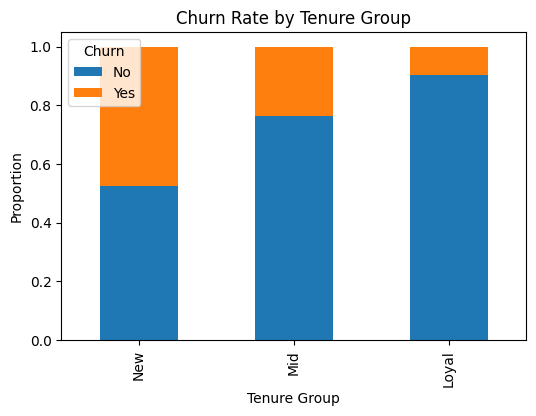

In [25]:
ct = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(6,4))

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Proportion')
plt.legend(title='Churn')
plt.show()

#### **Insights**
* New (0–12 months): ~48% churn — nearly half of new customers leave early
* Mid (13–48 months): ~23% churn — moderate, stabilising phase 
* Loyal (49–72 months): ~8% churn — long-term customers are highly retained
** →** This confirms the business priority: focus retention efforts on the first 12 months.

# Section 5 — EDA (Analysis before plots)

## **5.1** Outlier Check

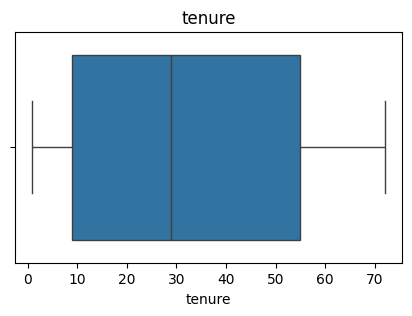

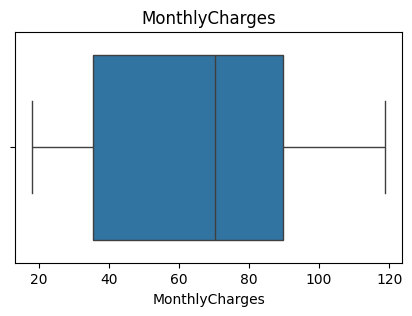

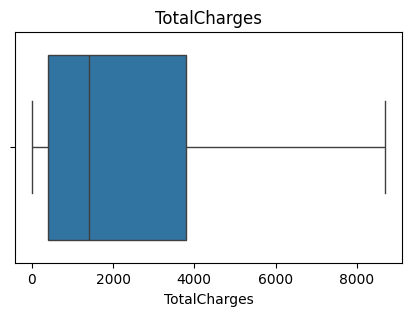

In [26]:
for col in num_cols:
    if col != 'SeniorCitizen':
        plt.figure(figsize=(5,3))
        sns.boxplot(x=col, data=df)
        plt.title(col)
        plt.show()

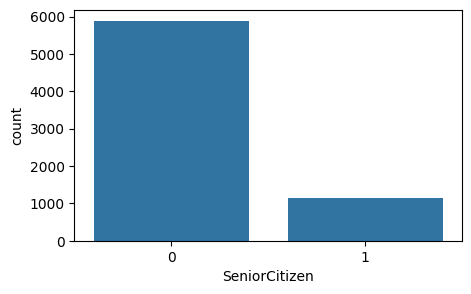

In [27]:
plt.figure(figsize=(5,3))
sns.countplot(x='SeniorCitizen', data=df)
plt.show()

#### **Insights**
* **tenure:** fairly uniform spread from 0–72, no extreme values.
* **MonthlyCharges:** slight right spread, values range ~20–118, no true outliers.
* **TotalCharges:** right-skewed with a long upper tail — this is natural (long-term customers accumulate higher total charges), not noise.
* **SeniorCitizen:** binary 0/1 — boxplot not meaningful here, Outliers are about extreme continuous values.
                        Binary data has: -> No “extreme” values, -> Just two categories. So we drawn it as a countplot

**→ No outlier removal needed for any column.**

## **5.2**  Churn Rate % Per Category

In [28]:
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    print("\n"+"="*30)
    print(churn_rate)


gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64

Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64

Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64

PhoneService
No     25.000000
Yes    26.747481
Name: Churn, dtype: float64

MultipleLines
No                  25.081241
No phone service    25.000000
Yes                 28.648466
Name: Churn, dtype: float64

InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64

OnlineSecurity
No                     41.778667
No internet service     7.434211
Yes                    14.640199
Name: Churn, dtype: float64

OnlineBackup
No                     39.941691
No internet service     7.434211
Yes                    21.567010
Name: Churn, dtype: float64

DeviceProtection
No                     39.140271
No internet service     7.434211
Yes                    22.539289
Name: Churn, dtype: float64

TechSupport
No      

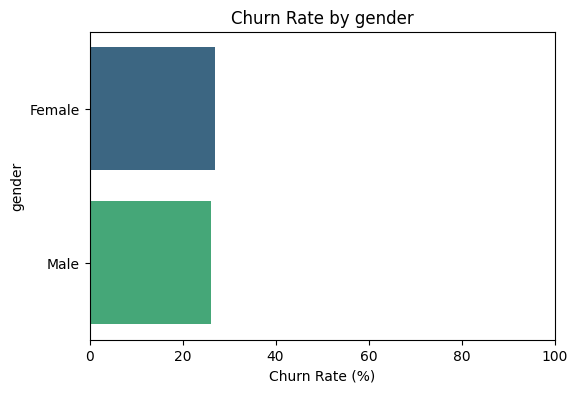

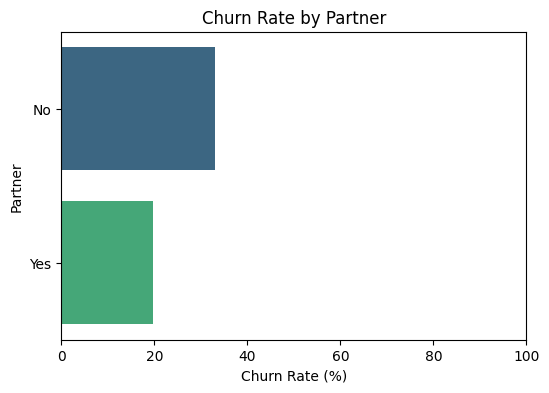

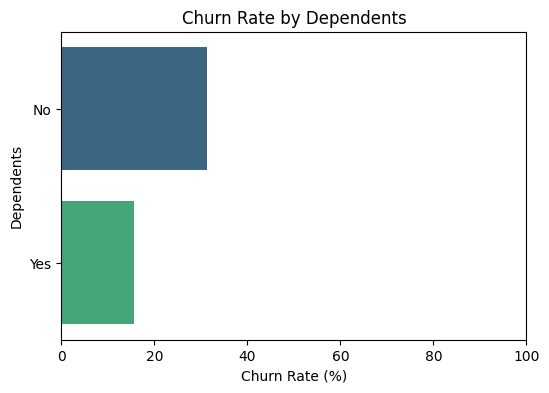

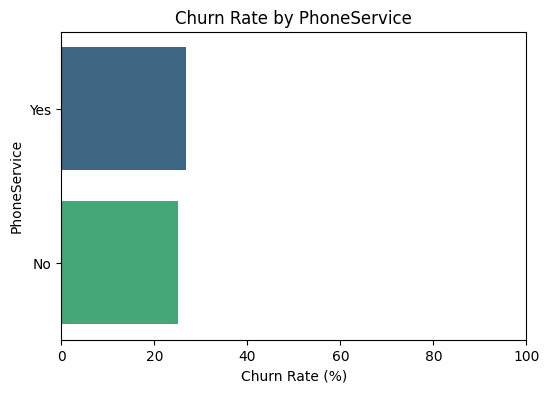

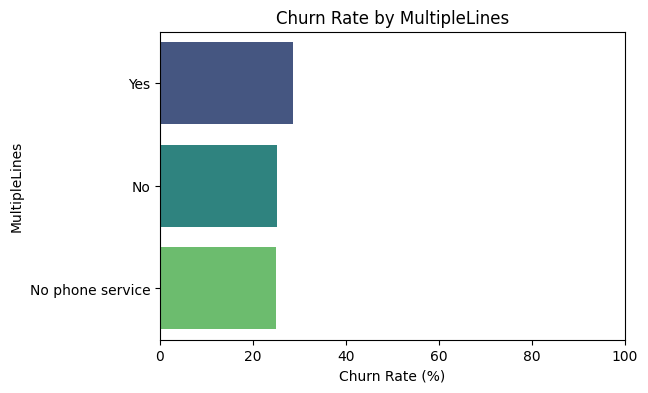

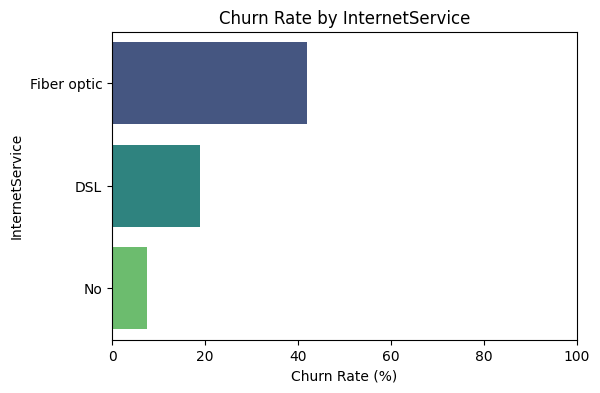

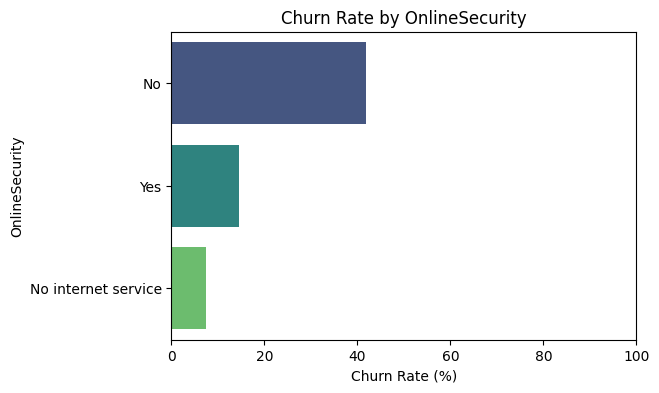

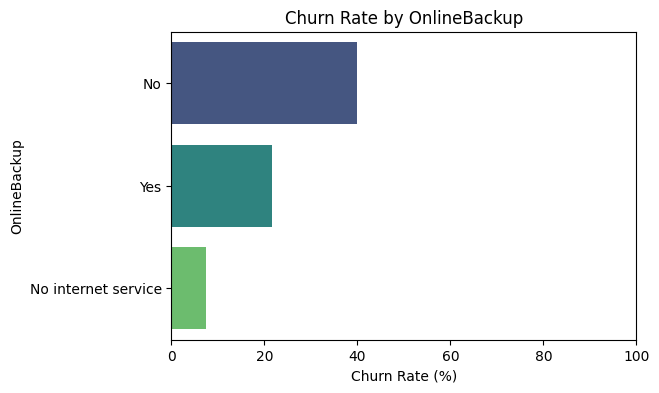

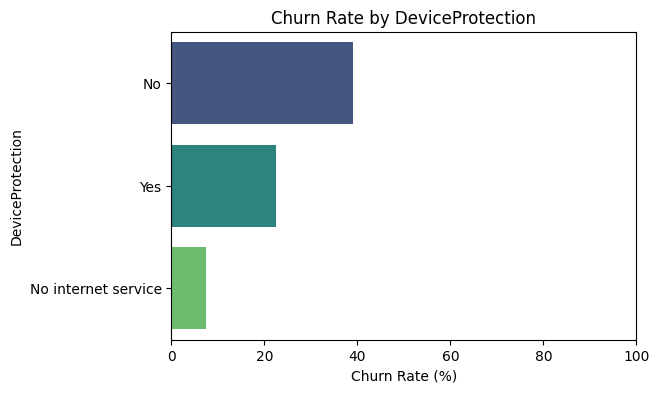

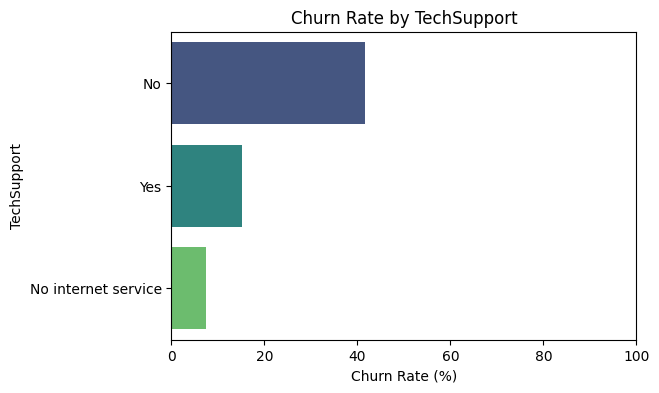

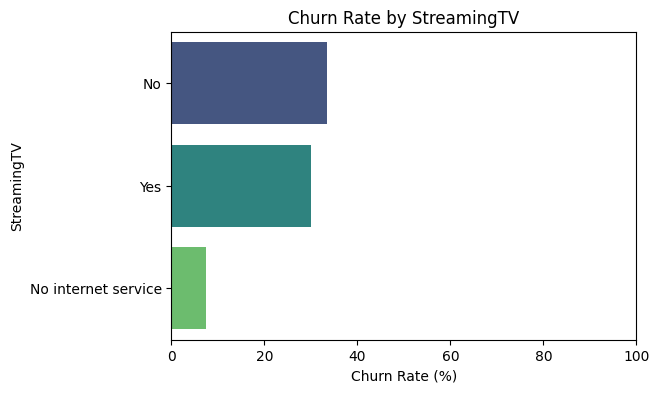

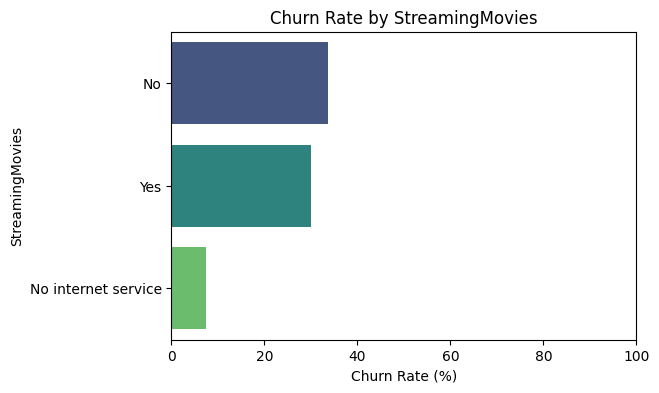

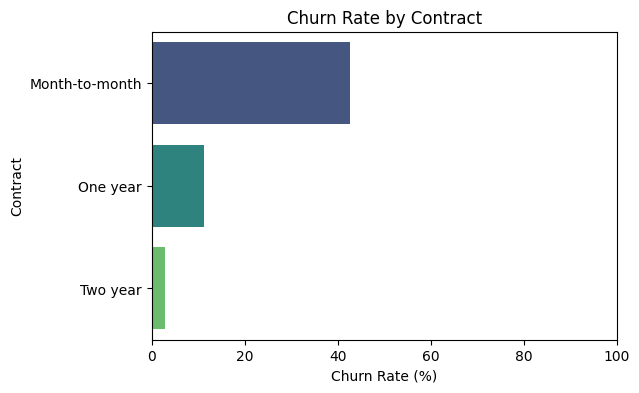

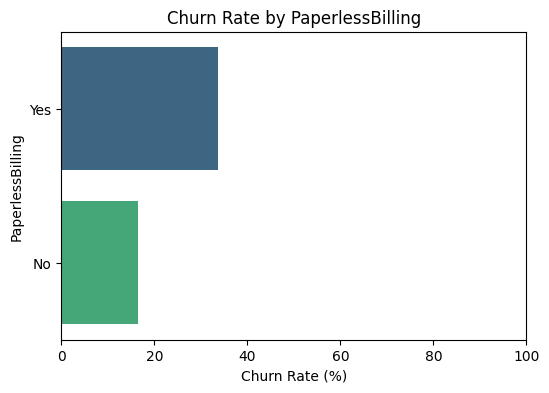

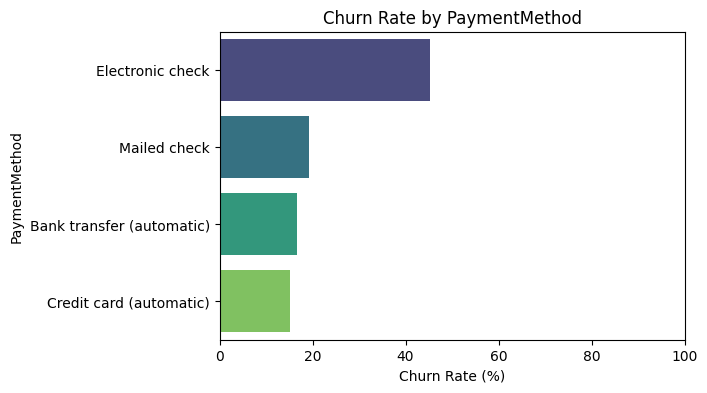

In [29]:
for col in cat_cols:
    churn_rate = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index(name='ChurnRate')
    )
    
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=churn_rate,
        y=col,
        x='ChurnRate',
        palette='viridis'
    )
    
    plt.title(f'Churn Rate by {col}')
    plt.xlabel('Churn Rate (%)')
    plt.ylabel(col)
    plt.xlim(0, 100)
    
    plt.show()

### Top 5 services in which customers  are likely to be churn are

**1.** Month-to-month contracts drive highest churn
* Customers with month-to-month contracts (42.7%) churn far more than those on one-year (11.3%) or two-year (2.8%) plans.
**->** Insight: Lack of long-term commitment strongly increases churn risk.
    
**2.** Fiber optic users have very high churn
* Customers using fiber optic internet (41.9%) churn much more than DSL (19.0%) or no internet (7.4%).
**->** Insight: Possible issues with pricing, expectations, or service quality.

**3.** Lack of support services = high churn
* Customers without:
Online security (41.8%)
Tech support (41.6%)
Online backup (39.9%)
have significantly higher churn.
**->** Insight: Value-added services improve retention.

**4.** Electronic check users churn the most
* Customers using electronic check (45.3%) show the highest churn among payment methods.
**->** Insight: This group may face friction, lower trust, or weaker engagement.

**5.** Customers without family ties are more likely to churn
* No partner: 33.0% vs Yes: 19.7%
* No dependents: 31.3% vs Yes: 15.5%
**->** Insight: Customers with stronger household ties are more stable.

In [30]:
## Chi-Square Test

results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 2),
        'p-value': round(p_value, 4),
        'Degrees of Freedom': dof,
        'Significant (p<0.05)': p_value < 0.05
    })

chi2_results = pd.DataFrame(results).sort_values('p-value')
chi2_results

,Feature,Chi2 Statistic,p-value,Degrees of Freedom,Significant (p<0.05)
1,Partner,157.50,0.0000,1,True
2,Dependents,186.32,0.0000,1,True
6,OnlineSecurity,846.68,0.0000,2,True
5,InternetService,728.70,0.0000,2,True
7,OnlineBackup,599.18,0.0000,2,True
10,StreamingTV,372.46,0.0000,2,True
9,TechSupport,824.93,0.0000,2,True
8,DeviceProtection,555.88,0.0000,2,True
12,Contract,1179.55,0.0000,2,True
13,PaperlessBilling,256.87,0.0000,1,True


### Chi-Square Test Insights

Chi-square test of independence was performed on all 15 categorical features 
against the target variable (Churn) to statistically validate visual findings 
from EDA. Null hypothesis: the feature and Churn are independent (no relationship).

**Key findings:**

- 13 out of 15 features reject the null hypothesis (p < 0.05), confirming 
  a statistically significant relationship with Churn.

- Contract has the highest chi2 statistic (1179.55), making it the strongest 
  categorical predictor of churn — consistent with the 43% churn rate seen 
  in month-to-month contracts during EDA.

- OnlineSecurity (846.68) and TechSupport (824.93) follow closely, confirming 
  that missing add-on services are genuinely linked to higher churn, not a 
  visual coincidence.

- MultipleLines is significant (p=0.0036) but has a very low chi2 (11.27), 
  meaning the relationship exists but is weak — treat it as a low-priority feature.

- gender (p=0.49) and PhoneService (p=0.35) are NOT significant. 
  These features will be dropped during feature engineering as they add 
  noise without predictive value.

**Modeling implication:** 
13 statistically validated features will be carried into the modeling phase. 
gender and PhoneService will be excluded.

## **5.3** Correlation heatmap

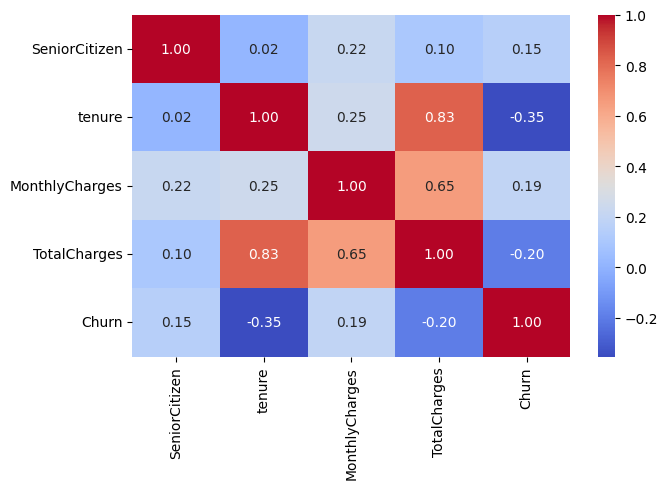

In [31]:
df_corr = df.copy()
df_corr['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(7,5))
sns.heatmap(df_corr[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

#### Insights
**Churn vs tenure(-0.35)** -> Strong Negative 
* Customers with higher tenure are less likely to churn
* Meaning: Long-term customers are more loyal

**Churn vs MonthlyCharge(0.19)** -> Slight Positive
* Higher monthly charges - slightly more churn
* Meaning: Customers paying more may feel it's expensive

**Churn vs TotalCharges(-0.20)** -> Negative
* Customers with higher total spending churn less 
* These are long-term + high-value customers

**Churn vs SeniorCitizen(0.15)** -> Weak Positive
* Senior citizen are slightly more likely to churn

**Important Insight :**

**Tenure vs TotalCharges(0.83)** -> Very Strong
    * Longer stay - more total spending

 **MonthlyCharges vs TotalCharges(0.65)** -> Strong
    * Higher monthly - higher total charges

# Section 6 — Data Visualization

## **6.1**  Univariate — Categorical

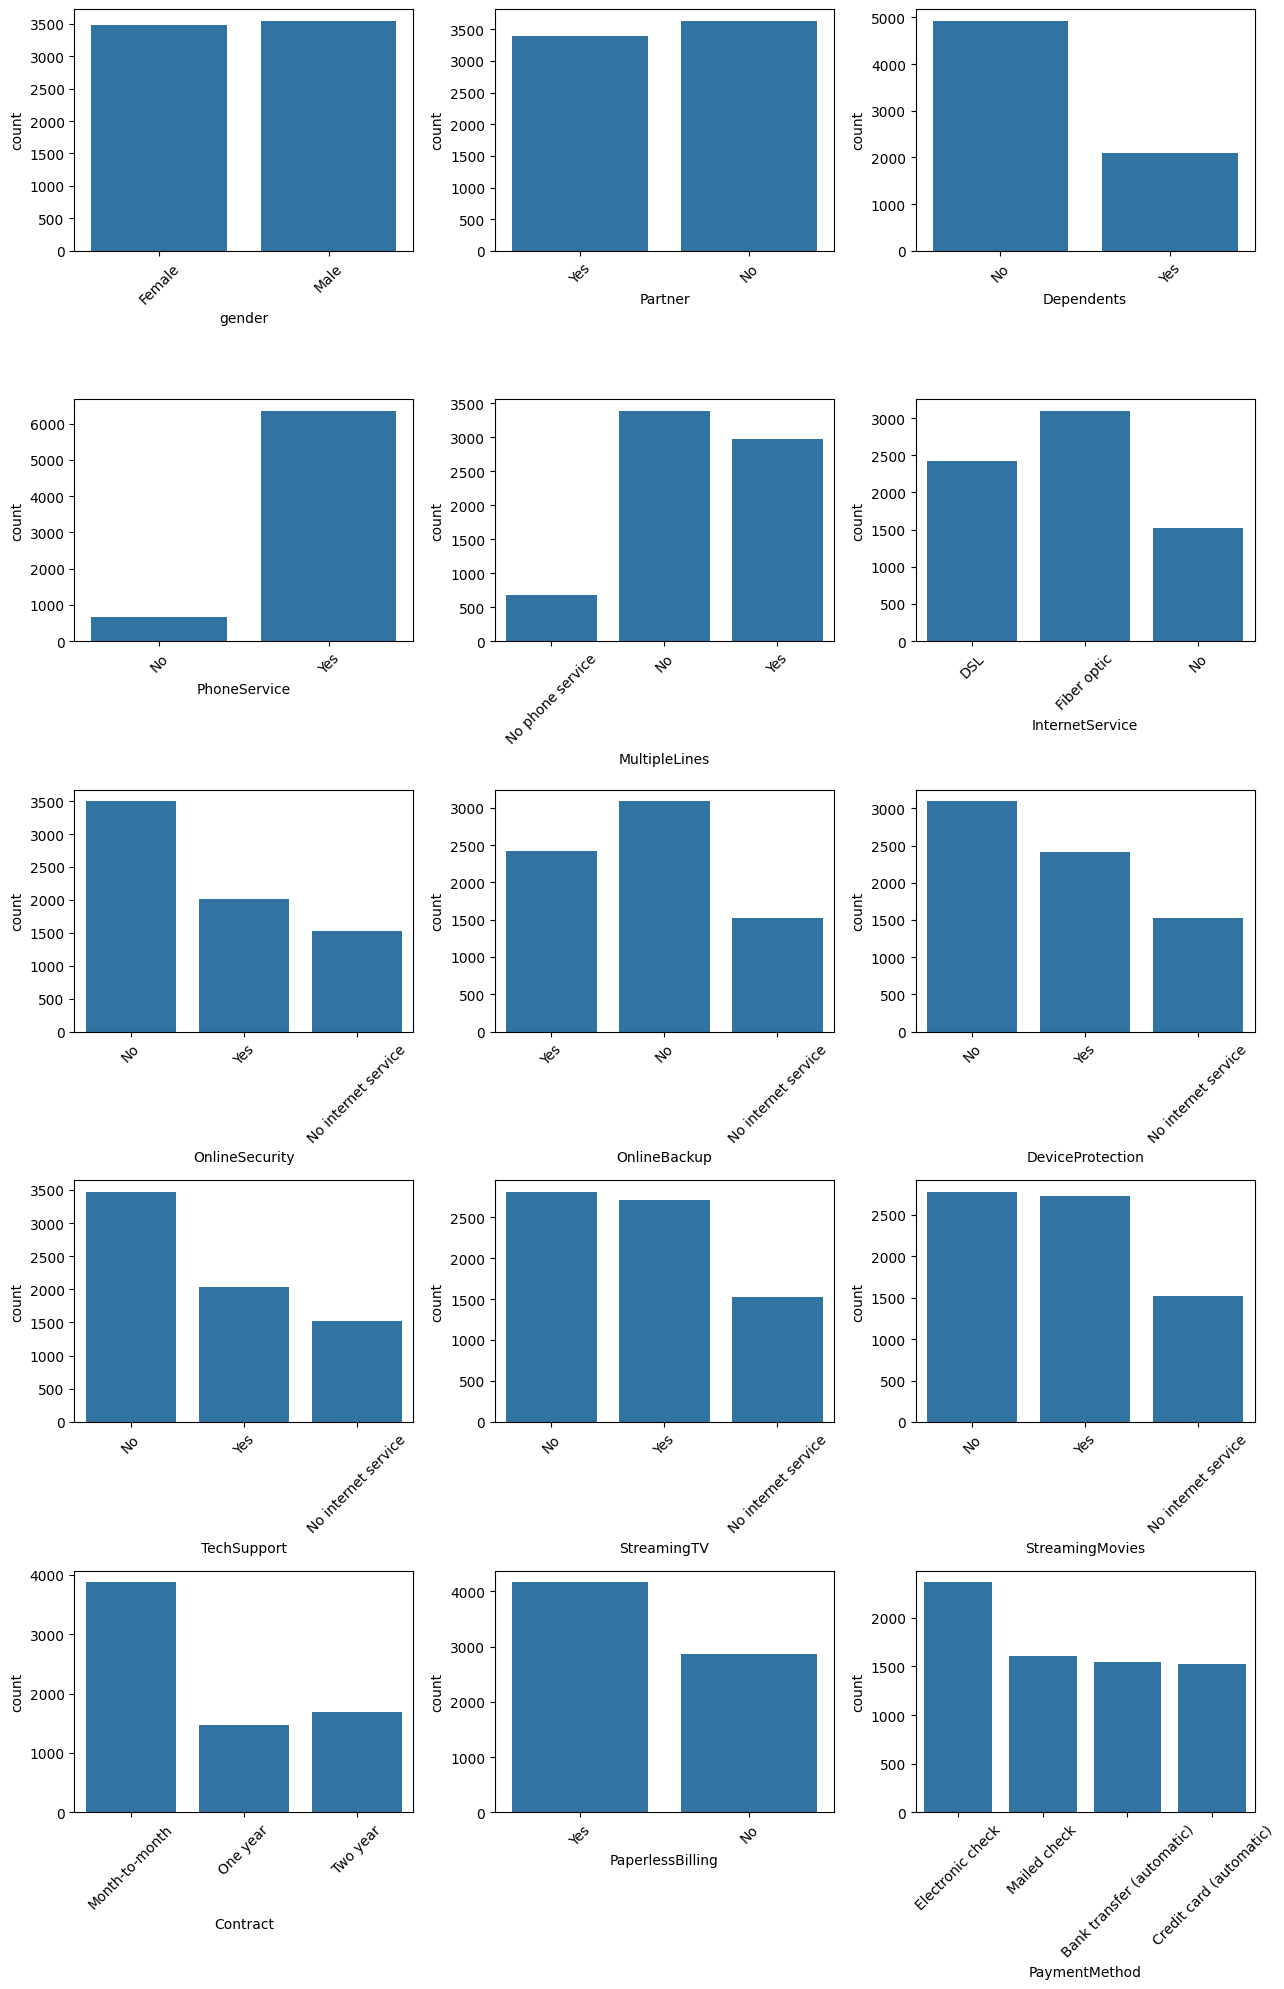

In [32]:
plt.figure(figsize=(13, 20))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 3, i+1)  # adjust rows/cols
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
for col in cat_cols:
    print("\n", "="*50)
    print(col)
    print("="*50)
    
    percent = df[col].value_counts(normalize=True) * 100
    count = df[col].value_counts()
    
    summary = pd.DataFrame({
        "Count": count,
        "Percentage": percent.round(2)
    })
    
    print(summary)


gender
        Count  Percentage
gender                   
Male     3549       50.47
Female   3483       49.53

Partner
         Count  Percentage
Partner                   
No        3639       51.75
Yes       3393       48.25

Dependents
            Count  Percentage
Dependents                   
No           4933       70.15
Yes          2099       29.85

PhoneService
              Count  Percentage
PhoneService                   
Yes            6352       90.33
No              680        9.67

MultipleLines
                  Count  Percentage
MultipleLines                      
No                 3385       48.14
Yes                2967       42.19
No phone service    680        9.67

InternetService
                 Count  Percentage
InternetService                   
Fiber optic       3096       44.03
DSL               2416       34.36
No                1520       21.62

OnlineSecurity
                     Count  Percentage
OnlineSecurity                        
No              

#### **Insights**
1.The dataset is mostly balanced across gender and partner.

2.Most customers:
* Are not dependent(~70%)
* Have phone service(~90%)
* Use fiber optic internet(~44%)
* Do not subscribe to add-on services(OnlineSecurity(~50%), OnlineBackup(~44%), DeviceProtection(~44%))
* Do not have TechSupport(~49%)
* Prefer PaperlessBilling(~59%)
* Using Electronic Check as  PaymentMethod(~33%)
3. Month-to-Month(~55%) contract customers are more than One year(~21%) and Two year(~24%) 

**Note: tenure_group (Categorical dtype) is excluded here — it is analysed in Section 4.3**

## **6.2**  Univariate — Numerical

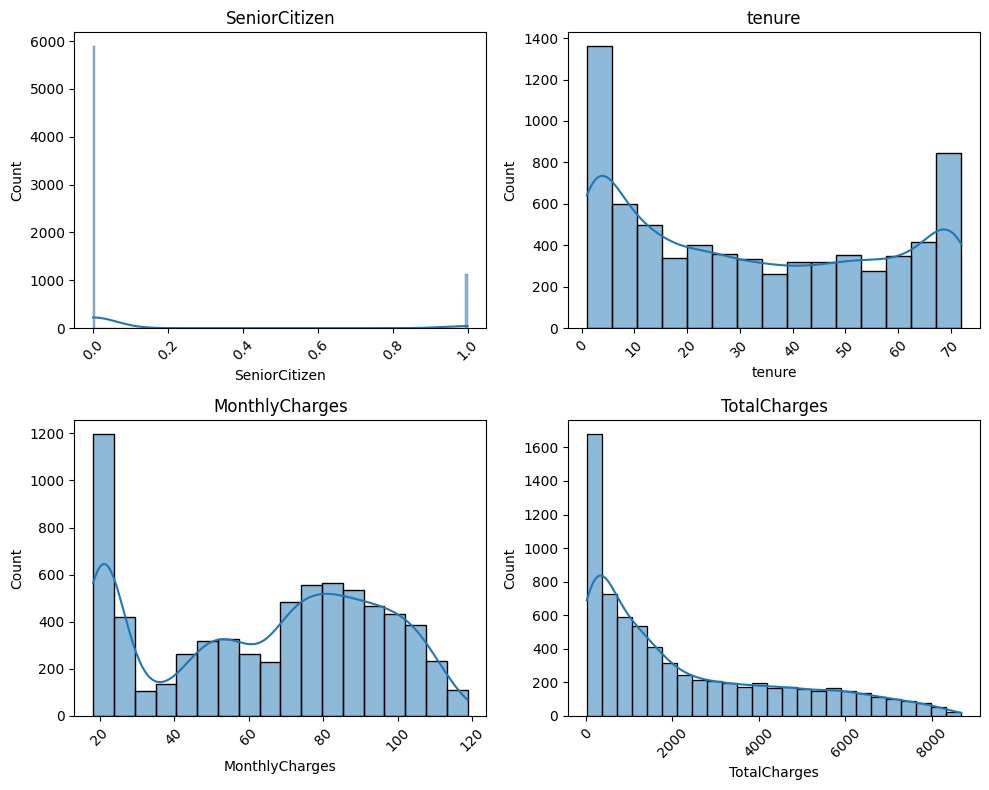

In [34]:
plt.figure(figsize=(10, 8))

for i , col in enumerate(num_cols):
    plt.subplot(2, 2, i+1) # adjust rows/columns
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### **--Insights--**
**SeniorCitizen** 
* This is a binary feature
* This graph clearly shows - Most customers are **NOT** senior citizens(0) , very few are senior citizens(1)

**Tenure**: bimodal-
* bimodal-large spike at 0–5 months (new customers) and another at 60–72 months (loyal)
* Meaning->Many customers either leave very early or stay very long

**MonthlyCharges**
*  bimodal peaks near ~ 20 (basic/DSL) and ~ 80 (fiber optic) — suggests two distinct customer segments by service tier

**TotalCharges**
*  right-skewed — most customers have low total charges (short tenure), a smaller group of loyal customers accumulate high totals.

**SeniorCitizen**
* ~84% non-senior (0), ~16% senior (1) — heavily skewed binary feature.


## **6.3**  Bivariate — Categorical vs Churn

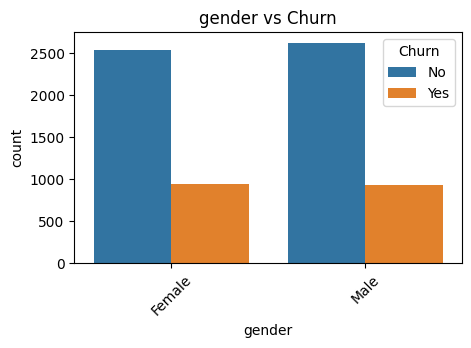

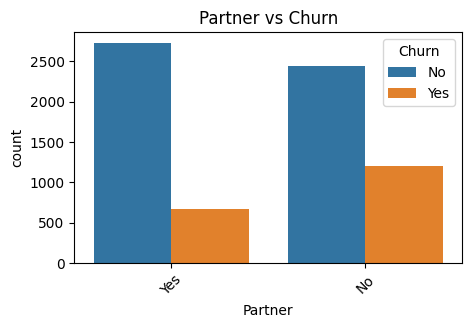

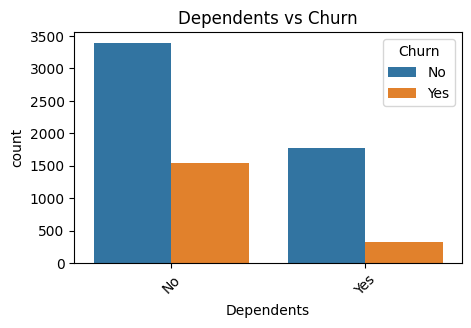

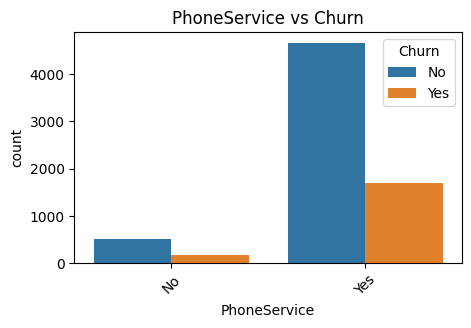

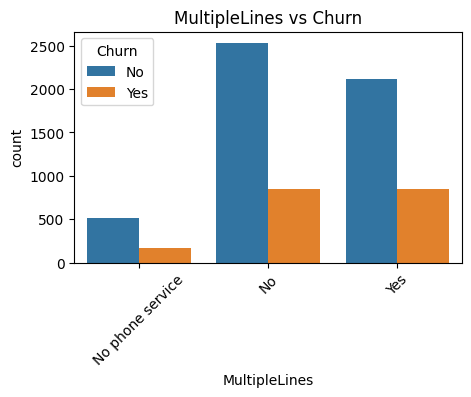

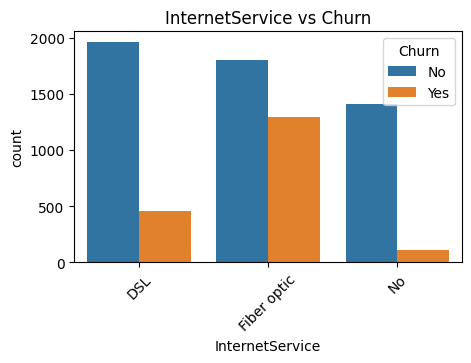

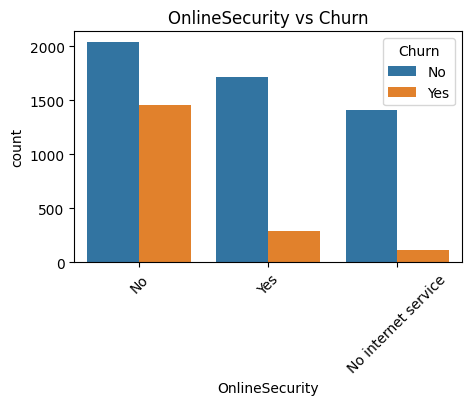

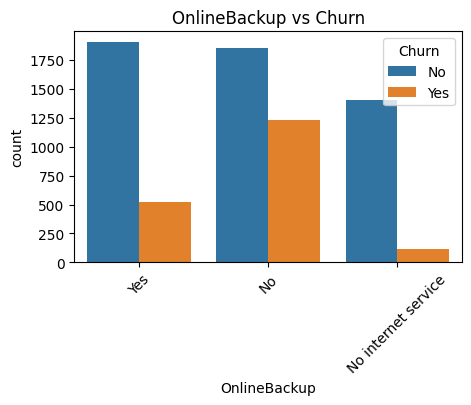

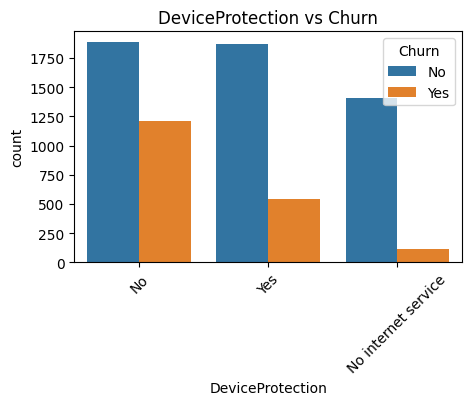

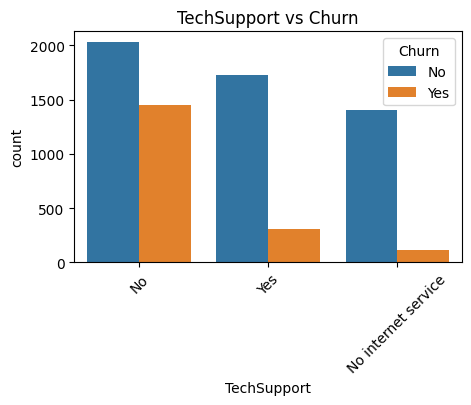

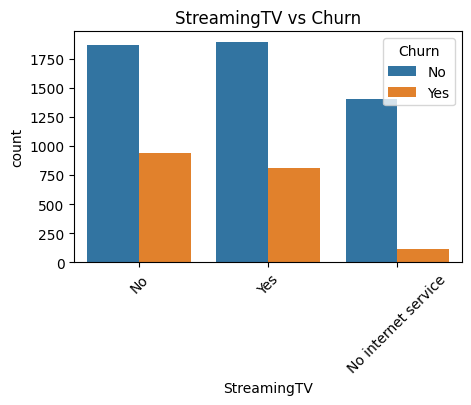

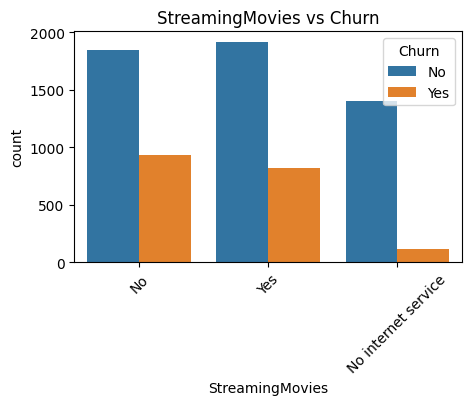

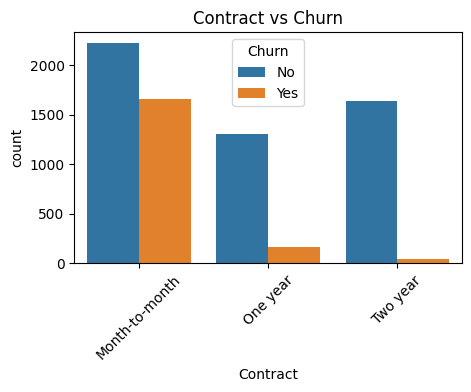

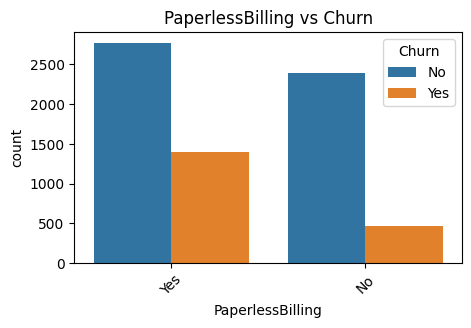

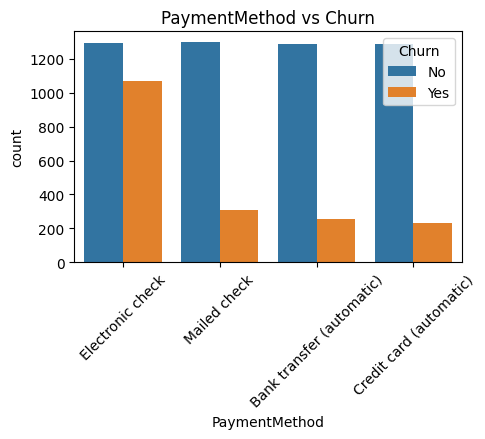

In [35]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

#### **Insights**
* Gender is not seems to be the reason for customers to churn
* Customers who are not partner and not dependents are likely to churn more
* PhoneService: despite more churners having phone service in absolute count, churn rates are nearly equal (~26% Yes vs ~25% No) — this is because 90% of customers have phone service. PhoneService is not a meaningful predictor of churn.
* Customers having internet service and using Fiber optic are likely to churn more as compared to DSL and who don't have internet service
* Who do not have Add-on services(OnlineSecurity,OnlineBackup, DeviceProtection) are likely to churn more
* Customers do not have TechSupport also be the reason to churn
* Month-to-Month to contract have the high numbers of customer who are likely to churn
* Paperlessbilling is also a reason, meaning customers opted for PaperlessBilling churn more
* Customer who  choose Electronic check as a  payment method are likely to churn more

## **6.4**  Bivariate — Numerical vs Churn (boxplots)

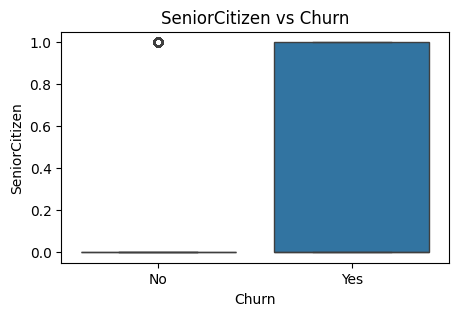

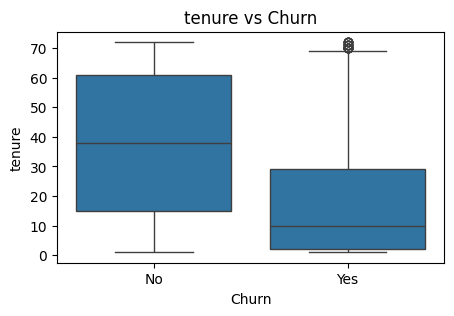

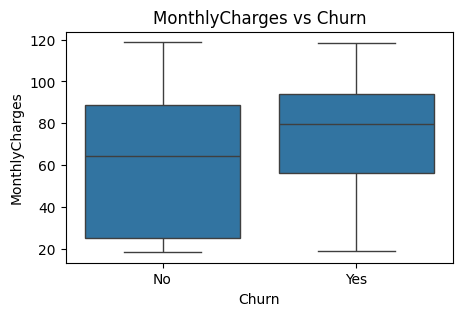

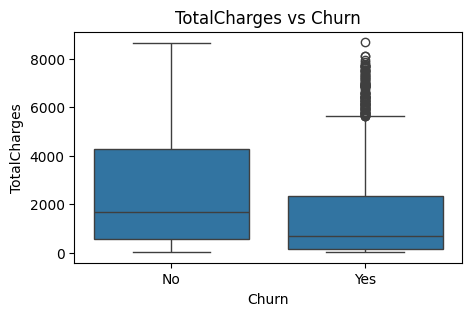

In [36]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

### **Insight**
* Customers are far more likely to churn early in their lifecycle of **tenure** , meaning less the tenure more likely to churn
* Customers who churn generally pay **more per month** than those who stay , meaning higher price - higher churn risk
* Customers who churn generally have lower TotalCharges, indicating they leave early.
* Customers with higher TotalCharges tend to stay longer, contributing more revenue and showing higher retention

## **6.5**  Pairplot

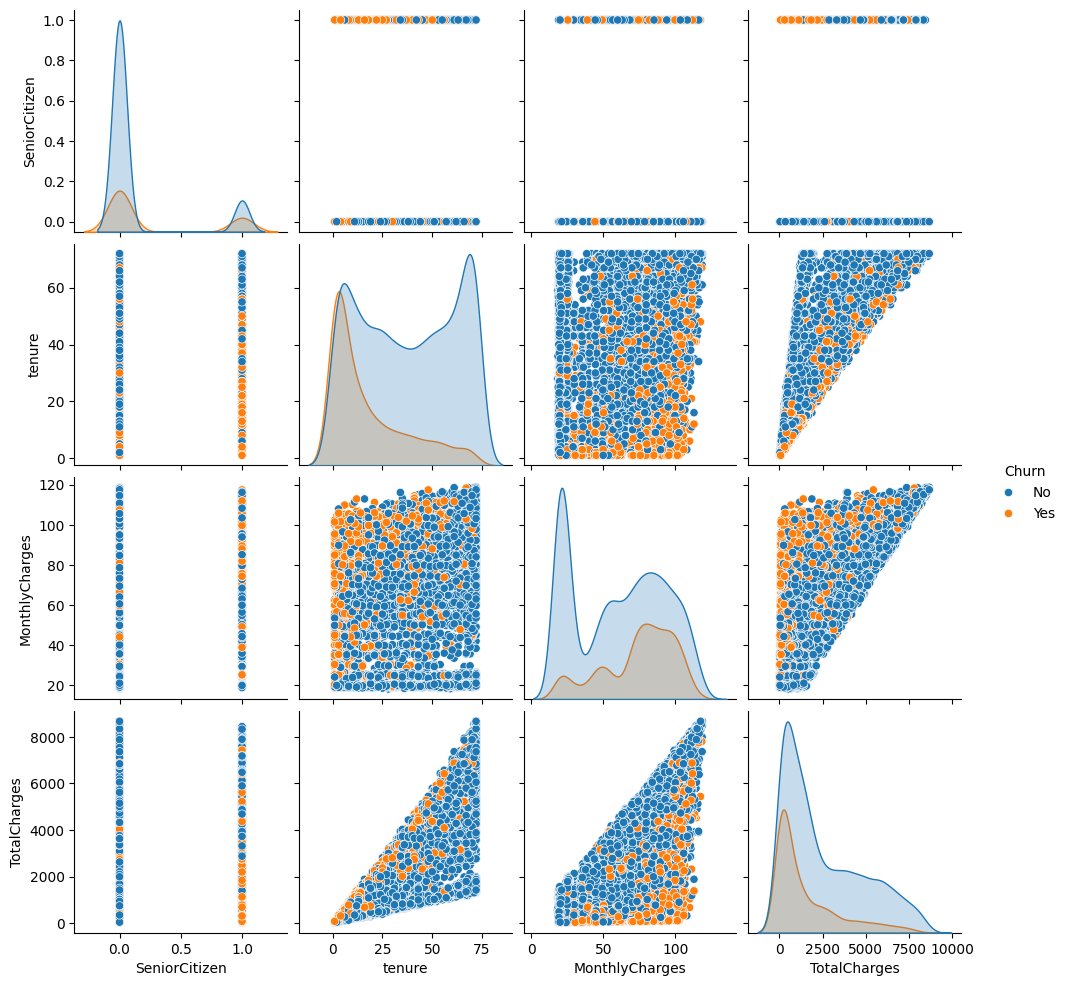

In [37]:
sns.pairplot(df[num_cols + [target]], hue=target)
plt.show()

#### **Insight**
* Churned (orange) and non-churned (blue) clusters overlap significantly in all numeric features — no single feature perfectly separates the two classes. Tenure shows the clearest visual separation. This confirms that a model must combine multiple features to predict churn accurately, making it a good problem for ensemble methods like Random Forest or XGBoost.

## **6.6**  Multivariate — tenure vs MonthlyCharges scatterplot

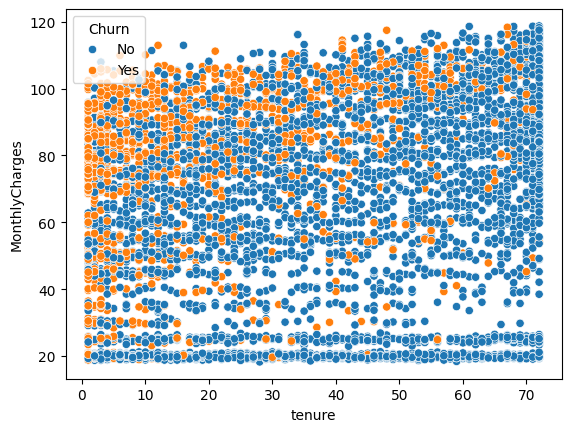

In [38]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue=target, data=df)
plt.show()

### **Insights**
* Customer with **lower tenure and higher MonthlyCharges** are shows the highest churn, meaning new customers on expensive MonthlyCharges are most likely to leave.
* As **tenure increases, churn decreases**, even for higher monthly charges, indicating long-term customers are more loyal despite pricing.
* Customers with **low monthly charges and higher tenure** have the lowest churn, representing the most stable segment.

# SUMMARY

## PART 1: Business Insights from the EDA
### Here is what this notebook tells the telecom business:
**1. Month-to-month contract is the #1 churn driver.** ~43% of month-to-month customers leave vs only 3% on two-year contracts. The business must incentivize contract upgrades aggressively — discounts for switching to annual plans are an immediate action item.

**2. The first 12 months are critical.** Nearly 48% of customers in the 0–12 month tenure group churned. Once a customer crosses 48 months, churn drops to ~8%. This means onboarding experience, early engagement campaigns, and first-year discounts have the highest ROI.

**3. Fiber optic customers are paying more and leaving more.** 41.9% churn vs 19% for DSL. This is a pricing-perception problem — either the service quality doesn't match the price, or customers are switching to more competitive fiber providers.

**4. Customers without support services feel unprotected and leave.** Online Security (41.8%), Tech Support (41.6%), and Online Backup (39.9%) non-subscribers churn at roughly double the rate of subscribers. Bundling these as free add-ons for the first year could significantly reduce churn.

**5. Electronic check payment users churn the most (~45%).** These are likely customers with lower engagement and less "stickiness." Auto-pay users churn at just 15–18%. Moving customers to auto-pay should be a retention strategy.

**6. Solo customers (no partner, no dependents) are high-risk.** 33% churn vs 19.7% for customers with partners. They have fewer reasons to stay and more flexibility to switch.

**7. Gender and phone service are irrelevant.** Chi-square confirms p-values of 0.49 and 0.35 — these add noise, not signal.

## PART 2: What to Do in Model Training to Reduce Churn

**Encoding strategy:** Map all binary Yes/No columns to 1/0. One-hot encode Contract, PaymentMethod, InternetService. Collapse "No internet service" to "No" across all service columns before encoding.

**Handle class imbalance:** Start with *(class_weight='balanced')* in Logistic Regression and Random Forest. If results are still poor, apply SMOTE on training data only (never on test). Use AUC-ROC and F1-score as your metrics — not accuracy.

**Multicollinearity decision:** TotalCharges correlates 0.83 with tenure. Either drop TotalCharges or keep both and let tree models handle it. For logistic regression, drop it.

**Feature selection:** Drop *( gender)* and *(PhoneService)* (chi-square insignificant). Keep the engineered *(tenure_group)* alongside raw *(tenure)*.
Models to train in order: Logistic Regression (baseline) → Random Forest → XGBoost. Compare all three using 5-fold cross-validated AUC-ROC.

**Threshold tuning:** Default threshold is 0.5, but for churn you want higher recall (catch more churners even at cost of precision). Tune the threshold using precision-recall curve.

**Business-focused metric:** Calculate the cost-matrix — a missed churner (false negative) costs 5–7× more than a false alarm. Use this to justify a lower decision threshold in production.